<a href="https://colab.research.google.com/github/PericaRajcevic1/lab2-PericaRajcevic1/blob/main/lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
!rm -rf clone && git clone https://github.com/pui-sum-rv/lab1 clone && cp -a clone/. .


Cloning into 'clone'...
remote: Enumerating objects: 110, done.
remote: Counting objects: 100% (110/110), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 110 (delta 34), reused 80 (delta 19), pack-reused 0 (from 0)
Receiving objects: 100% (110/110), 6.53 MiB | 25.90 MiB/s, done.
Resolving deltas: 100% (34/34), done.


In [13]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt


In [14]:
def gaussian_noise(img, mu, sigma):
    # generiraj nasumicne brojeve Gaussove distribucije
    noise = np.random.normal(mu, sigma, img.shape)
    return noise.astype(np.uint8)

def salt_n_pepper_noise(img, percent=10):
    limit = ((float(percent)/2.0)/100.0) * 255.0
    noise = np.random.uniform(0, 255, img.shape)
    return noise.astype(np.uint8)


## Zadatak 1


(512, 512)


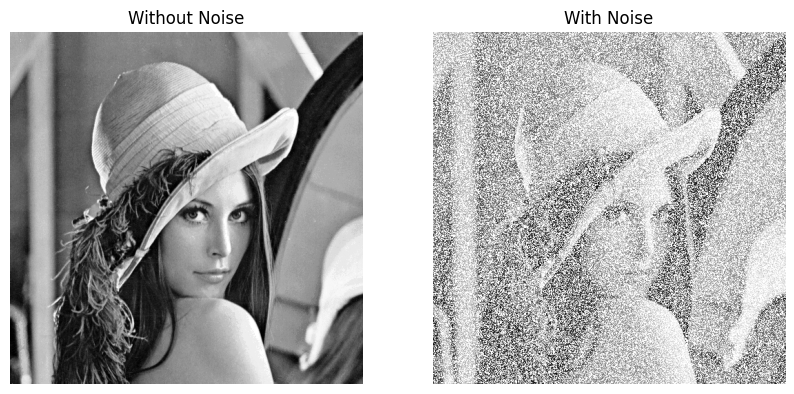

In [15]:
img = cv.imread("images/lenna.bmp", cv.IMREAD_GRAYSCALE)
print(img.shape)

noise = gaussian_noise(img, 0, 25)
img_noisy = cv.add(img, noise)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Without Noise")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(img_noisy, cmap="gray")
plt.title("With Noise")
plt.axis("off")
plt.show()


## Zadatak 2


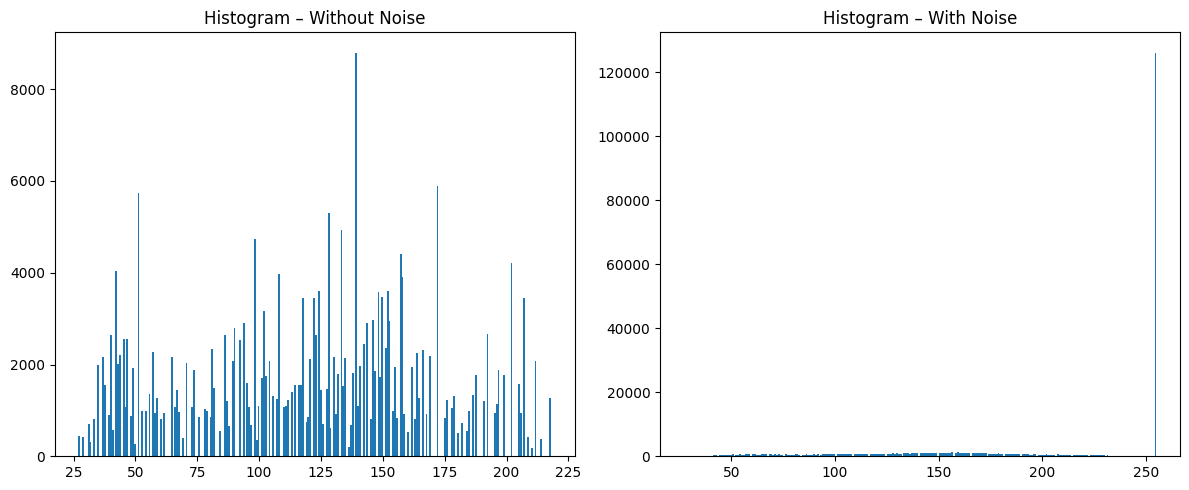

In [16]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(img.flatten(), bins=256)
plt.title("Histogram – Without Noise")
plt.subplot(1, 2, 2)
plt.hist(img_noisy.flatten(), bins=256)
plt.title("Histogram – With Noise")
plt.tight_layout()
plt.show()


## Zadatak 3


In [17]:
def uniform_noise(img, a, b):
    # uniformna distribucija u intervalu [a, b]
    noise = np.random.uniform(a, b, img.shape)
    return noise.astype(np.uint8)


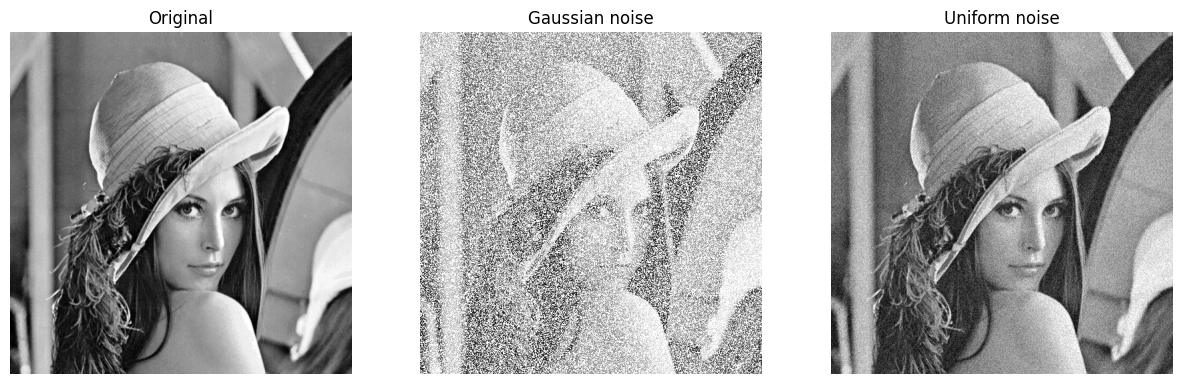

In [18]:
uni = uniform_noise(img, 0, 50)
img_uni = cv.add(img, uni)

gauss = gaussian_noise(img, 0, 25)
img_gauss = cv.add(img, gauss)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(img_gauss, cmap="gray")
plt.title("Gaussian noise")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(img_uni, cmap="gray")
plt.title("Uniform noise")
plt.axis("off")
plt.show()


## Zadatak 4


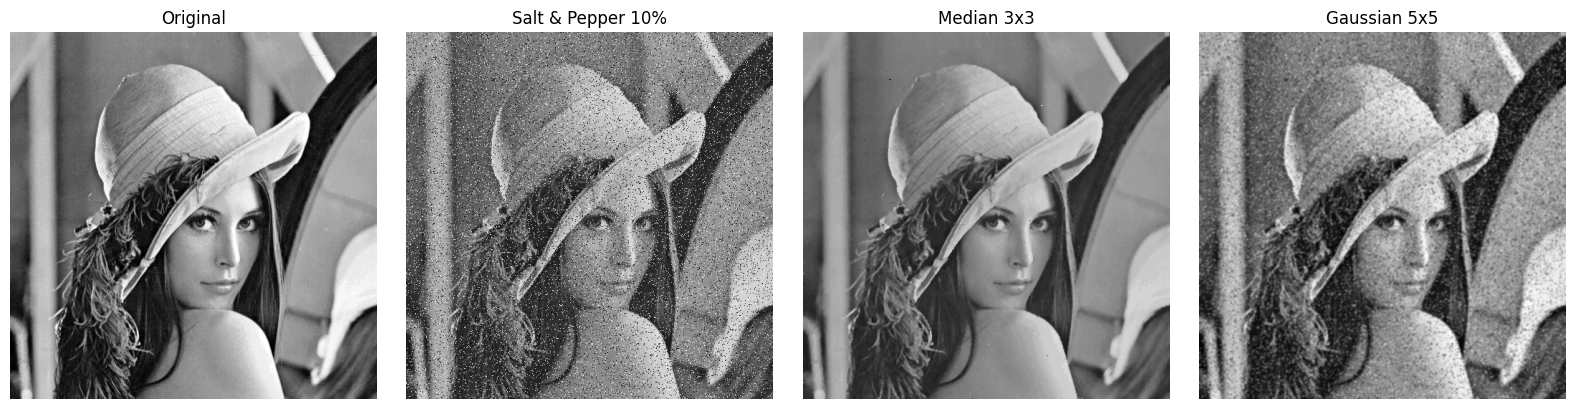

In [19]:
# salt and pepper 10%
img_sp = img.copy()
h, w = img.shape
n = int(h * w * 0.1)

r = np.random.randint(0, h, n // 2)
c = np.random.randint(0, w, n // 2)
img_sp[r, c] = 255  # salt (bijelo)

r = np.random.randint(0, h, n // 2)
c = np.random.randint(0, w, n // 2)
img_sp[r, c] = 0    # pepper (crno)

median_f = cv.medianBlur(img_sp, 3)
gauss_f = cv.GaussianBlur(img_sp, (5, 5), 0)

plt.figure(figsize=(16, 4))
plt.subplot(1, 4, 1); plt.imshow(img, cmap="gray"); plt.title("Original"); plt.axis("off")
plt.subplot(1, 4, 2); plt.imshow(img_sp, cmap="gray"); plt.title("Salt & Pepper 10%"); plt.axis("off")
plt.subplot(1, 4, 3); plt.imshow(median_f, cmap="gray"); plt.title("Median 3x3"); plt.axis("off")
plt.subplot(1, 4, 4); plt.imshow(gauss_f, cmap="gray"); plt.title("Gaussian 5x5"); plt.axis("off")
plt.tight_layout()
plt.show()


## Zadatak 5


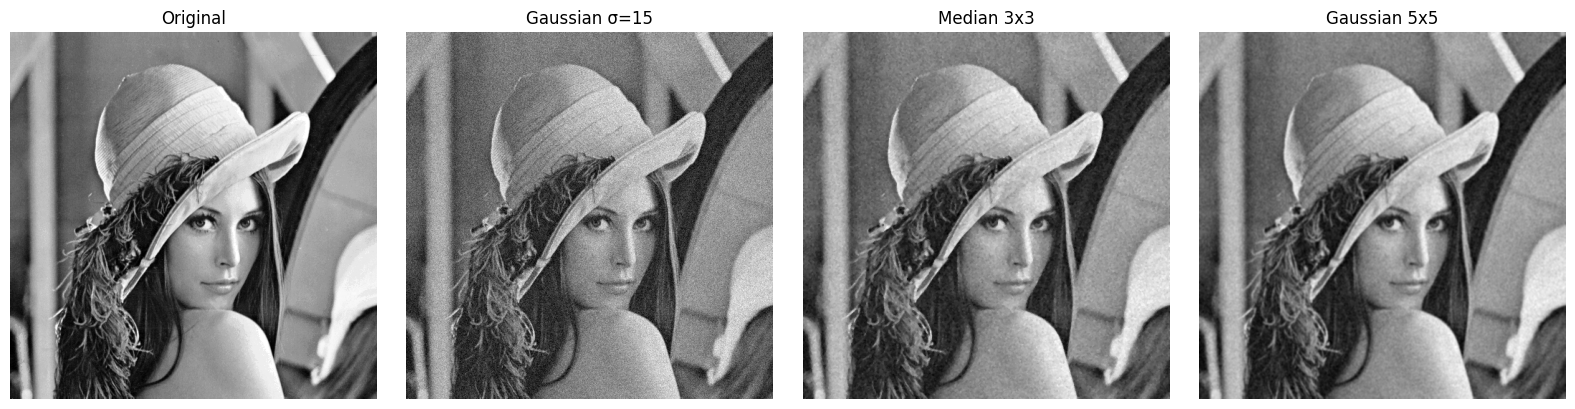

In [20]:
# gaussian noise sigma=15
g15 = np.random.normal(0, 15, img.shape)
img_g15 = np.clip(img.astype(np.float32) + g15, 0, 255).astype(np.uint8)

median_f = cv.medianBlur(img_g15, 3)
gauss_f = cv.GaussianBlur(img_g15, (5, 5), 0)

plt.figure(figsize=(16, 4))
plt.subplot(1, 4, 1); plt.imshow(img, cmap="gray"); plt.title("Original"); plt.axis("off")
plt.subplot(1, 4, 2); plt.imshow(img_g15, cmap="gray"); plt.title("Gaussian σ=15"); plt.axis("off")
plt.subplot(1, 4, 3); plt.imshow(median_f, cmap="gray"); plt.title("Median 3x3"); plt.axis("off")
plt.subplot(1, 4, 4); plt.imshow(gauss_f, cmap="gray"); plt.title("Gaussian 5x5"); plt.axis("off")
plt.tight_layout()
plt.show()
